In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../../../data/processed/DNA/signatures_per_sample.csv', index_col=0)

In [3]:
df_normalized = df / df.sum()

In [4]:
df=df_normalized.T

In [5]:
topics=pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx', index_col=0)

In [6]:
df.index=df.index.astype(int)

In [7]:
topics

,Date_start_HDM,DCABP_first_month,DCABP_general,Hyper_DCABP_month_1,Hyper_DCABP_general,DCABP_switch,Withdrawal,Exitus,PD_event,Obs_time,...,Menopause,ECOG,Hemoglobin_g_per_dL,Linfocytes_thousands_per_mm3,Neutrophils_thousands_per_mm3,Platelets_thousands_per_mm3,Albumin_g_per_dL,Corticoids,Beta_blockers,Opioids
S_RECORD_id,,,,,,,,,,,,,,,,,,,,,
12004,2025-02-05,NaN,NaN,NaN,NaN,NaN,1,0,0,22,...,1,0.0,13.6,1.93,4.90,280.0,4.17,0.0,0.0,0.0
23001,2023-06-01,NaN,NaN,NaN,NaN,NaN,0,1,1,28,...,1,0.0,14.0,0.50,4.85,158.0,3.80,1.0,0.0,1.0
23010,2024-12-02,NaN,NaN,NaN,NaN,NaN,1,0,0,18,...,0,0.0,12.0,1.61,8.22,862.0,3.70,0.0,0.0,0.0
52004,2025-05-14,NaN,NaN,NaN,NaN,NaN,0,1,1,30,...,0,NaN,12.1,1.90,7.08,329.0,3.98,NaN,NaN,NaN
63003,2024-10-04,NaN,NaN,NaN,NaN,NaN,0,1,1,156,...,1,0.0,11.0,1.90,11.40,530.0,3.80,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51016,2025-05-09,NaN,NaN,NaN,NaN,NaN,0,0,1,14,...,0,0.0,13.5,2.44,2.92,161.0,4.90,NaN,NaN,NaN
61004,2024-11-14,NaN,NaN,NaN,NaN,NaN,1,0,0,62,...,1,1.0,13.8,2.10,4.50,297.0,4.10,1.0,0.0,0.0
61006,2025-08-07,NaN,NaN,NaN,NaN,NaN,0,0,0,34,...,1,1.0,11.4,2.40,3.30,299.0,4.10,0.0,0.0,0.0


In [8]:
df=df.merge(topics[['Hyper_DCABP_general']], left_index=True, right_index=True)

In [9]:
df=df.sort_values(['SBS1','SBS6','SBS7b','SBS10b','SBS30','SBS87'], ascending=False)

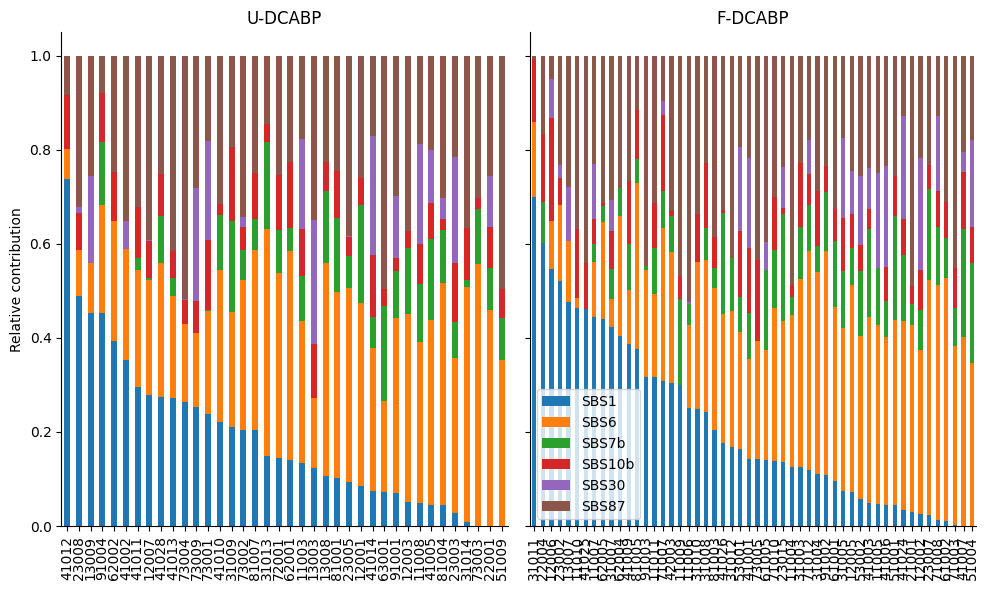

In [13]:
# Create subplots, share y-axis
fig, axes = plt.subplots(1, 2, figsize=(10,6), sharey=True)

# Plot group 0
df[df.Hyper_DCABP_general==0].drop(columns='Hyper_DCABP_general').plot(
    kind='bar', stacked=True, ax=axes[0], legend=False
)
axes[0].set_title('U-DCABP')
sns.despine(ax=axes[0])
axes[0].set_ylabel('Relative contribution')

# Plot group 1
df[df.Hyper_DCABP_general==1].drop(columns='Hyper_DCABP_general').plot(
    kind='bar', stacked=True, ax=axes[1]
)
axes[1].set_title('F-DCABP')
sns.despine(ax=axes[1])
axes[1].set_ylabel('Relative contribution')

plt.tight_layout()
#plt.savefig('signatures_by_group.svg')

In [14]:
from scipy.stats import mannwhitneyu
# Separate features
features = df.columns[:-1]

# Split into groups
group0 = df[df.Hyper_DCABP_general==0]
group1 = df[df.Hyper_DCABP_general==1]

# Run Mann-Whitney U test for each feature
p_values = {}
for feature in features:
    stat, p = mannwhitneyu(group0[feature], group1[feature], alternative='two-sided')
    p_values[feature] = p

# Show results
p_values_df = pd.DataFrame.from_dict(p_values, orient='index', columns=['p-value'])
print(p_values_df)

         p-value
SBS1    0.559125
SBS6    0.490003
SBS7b   0.552561
SBS10b  0.834904
SBS30   0.758271
SBS87   0.784341
